<a href="https://colab.research.google.com/github/bedkemanojkumar/mini-ml-projects-for-practice/blob/main/XAI_with_real_world_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("heart.csv")
df.head(10)

Saving heart.csv to heart (1).csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Hnadling Missing no missimg values

(df.isnull().mean() * 100).sort_values(ascending=False)

,0
age,0.0
sex,0.0
cp,0.0
trestbps,0.0
chol,0.0
fbs,0.0
restecg,0.0
thalach,0.0
exang,0.0
oldpeak,0.0


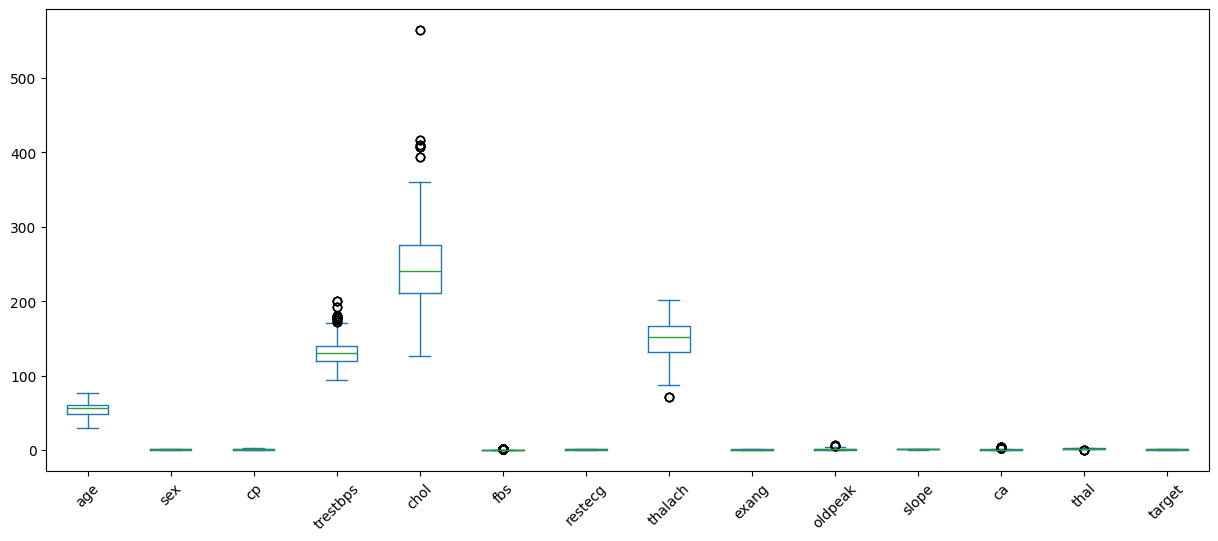

In [ ]:
import matplotlib.pyplot as plt

df.plot(kind='box', figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_capped = df.copy()
import numpy as np
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in continuous_cols:
  lower = Q1[col] - 1.5 * IQR[col]
  upper = Q3[col] + 1.5 * IQR[col]

  df_capped[col] = np.where(df[col] < lower, lower,
                      np.where(df[col] > upper, upper, df[col]))

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
age,0
sex,0
cp,0
trestbps,30
chol,16
fbs,153
restecg,0
thalach,4
exang,0
oldpeak,7


In [ ]:
valid_ranges = {
    "age": (0, 120),
    "chol": (100, 600),
    "trestbps": (50, 250),112
    "thalach": (50, 250)
}

In [ ]:
for col, (min_val, max_val) in valid_ranges.items():
    invalid = df[(df[col] < min_val) | (df[col] > max_val)]
    print(col, "invalid rows:", len(invalid))

age invalid rows: 0
chol invalid rows: 0
trestbps invalid rows: 0
thalach invalid rows: 0


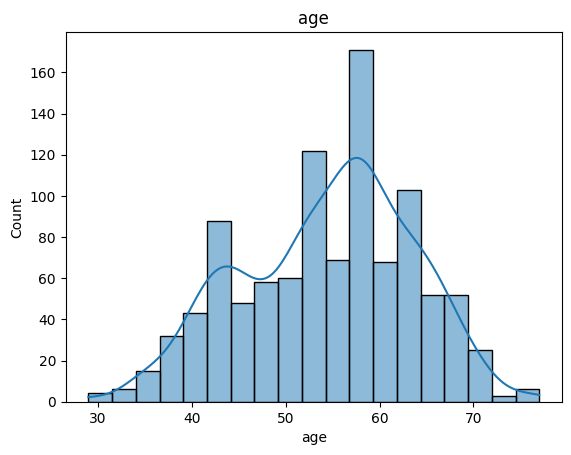

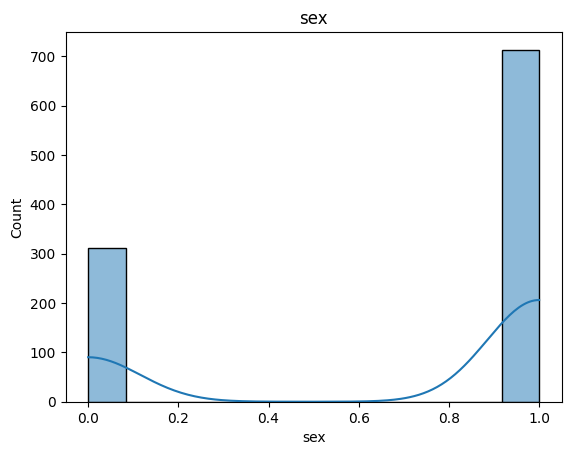

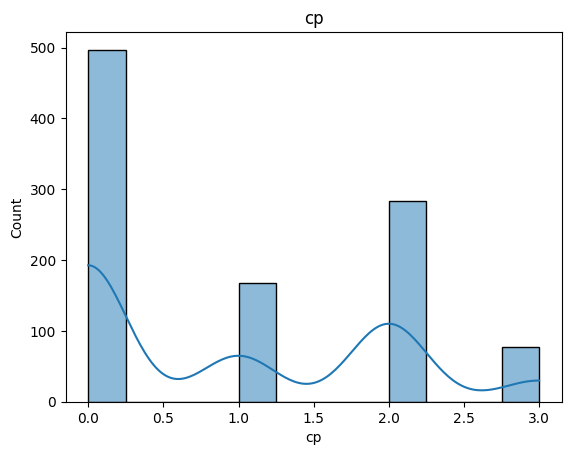

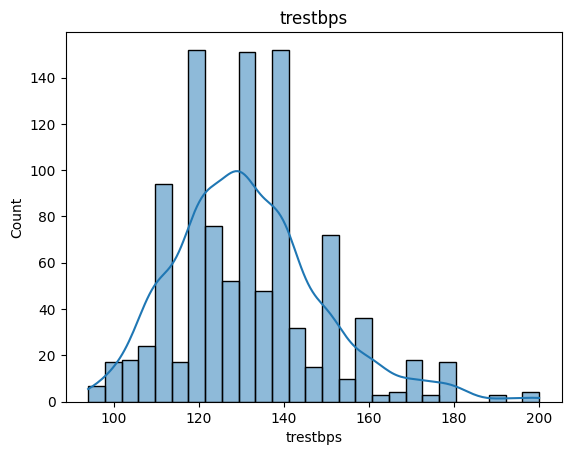

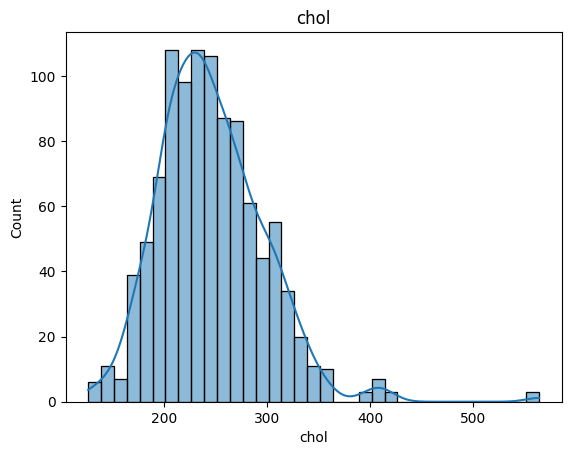

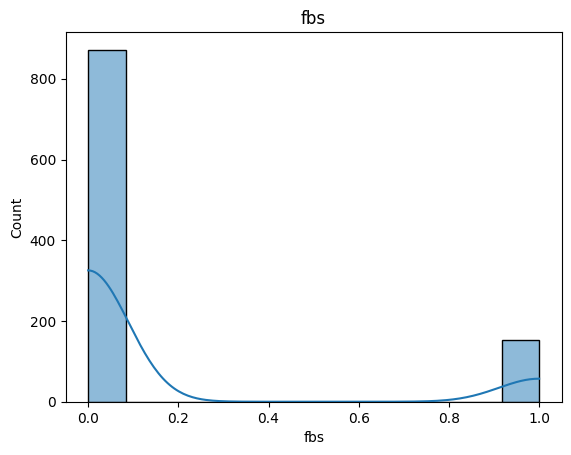

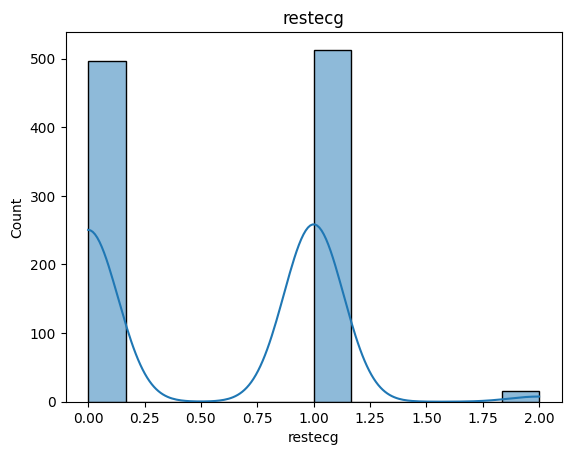

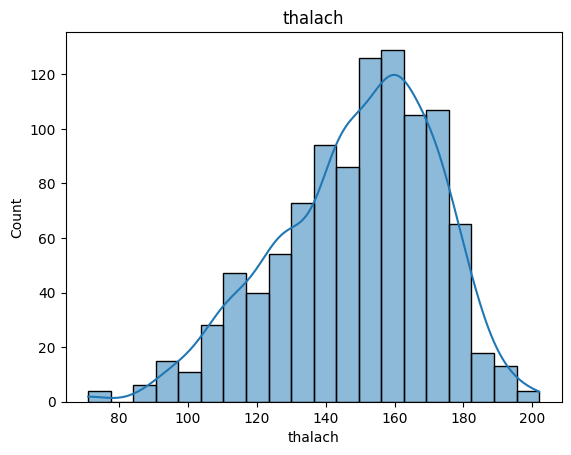

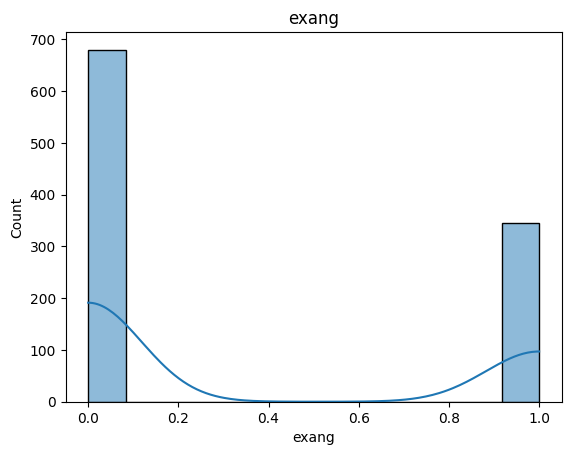

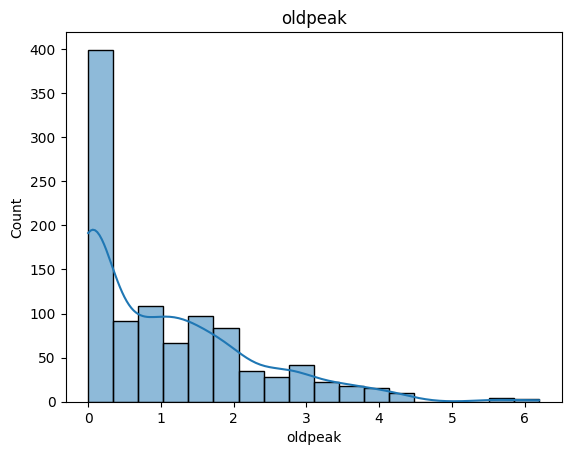

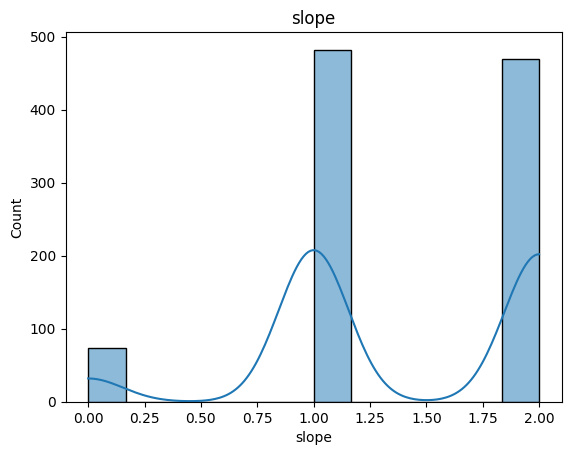

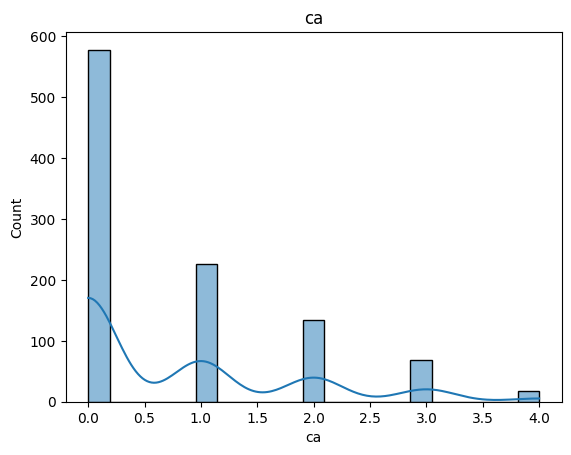

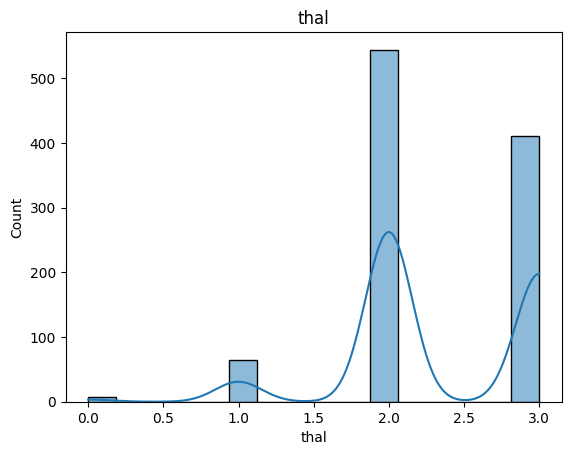

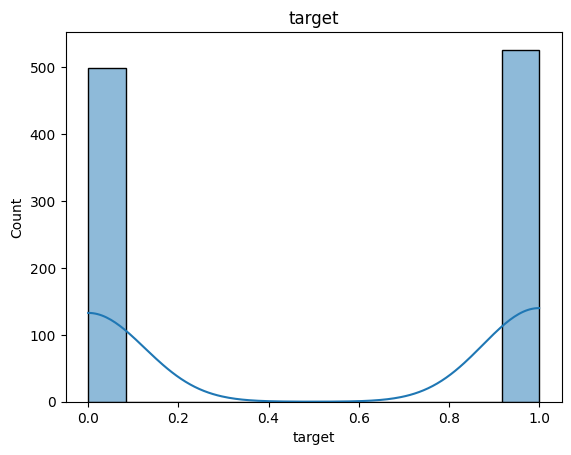

In [ ]:
import seaborn as sns

for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
print(df["restecg"].unique())
print(df["slope"].unique())
print(df["ca"].unique())
print(df["thal"].unique())

[1 0 2]
[2 0 1]
[2 0 1 3 4]
[3 2 1 0]


In [ ]:
df["target"].value_counts(normalize=True)

,proportion
target,
1,0.513171
0,0.486829


In [ ]:
# feature engineering

In [ ]:
df["age_group"] = pd.cut(df["age"], bins=[0,40,55,70,100], labels=["young","mid","senior","elder"])
df["high_chol"] = (df["chol"] > 240).astype(int)
df["bp_level"] = pd.cut(df["trestbps"], bins=[0,80,120,140,200], labels=["low","normal","high","very_high"])

# Drop originals that were replaced by engineered features
df.drop(columns=["age", "trestbps"], inplace=True)

X = df.drop("target", axis=1)

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
# Encoding

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
Slpit

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Check imbalance first
print("Class distribution:\n", y.value_counts(normalize=True))

# Option A — Let the model handle it (simplest, try this first)
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'   # ← adds this
)
model.fit(X_train, y_train)

Class distribution:
 target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


RandomForestClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=5,
                       n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.824390243902439
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       102
           1       0.79      0.89      0.84       103

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Training Accuracy ---
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# --- Testing Accuracy ---
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy: 0.9097560975609756
Testing Accuracy : 0.824390243902439


In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[77 25]
 [11 92]]


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.8760975609756099


In [ ]:
y_probs = model.predict_proba(X_test)[:,1]

# Lower threshold → higher recall
y_pred_custom = (y_probs > 0.4).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[70 32]
 [ 4 99]]
              precision    recall  f1-score   support

           0       0.95      0.69      0.80       102
           1       0.76      0.96      0.85       103

    accuracy                           0.82       205
   macro avg       0.85      0.82      0.82       205
weighted avg       0.85      0.82      0.82       205



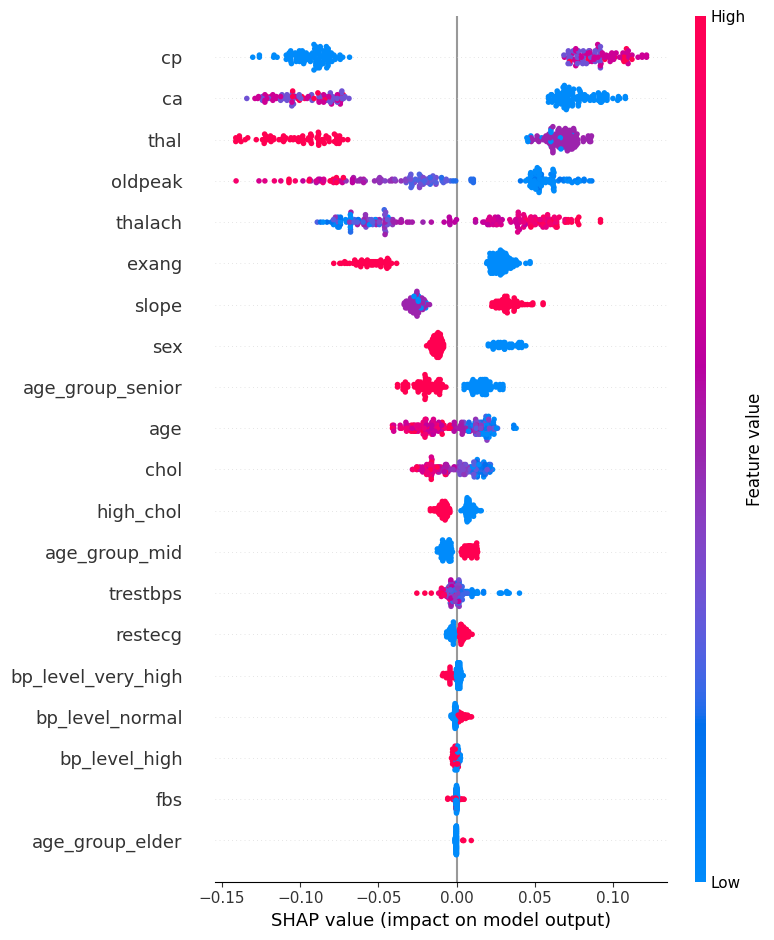

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# For binary classification, class index 1 = Disease
# Only one plot needed — drop the redundant first call
shap.summary_plot(shap_values[:, :, 1], X_test)

In [ ]:
# right_>inc diesease prob,left_> decrese prob
#Color
#→ Red = high feature value
#→ Blue = low feature value

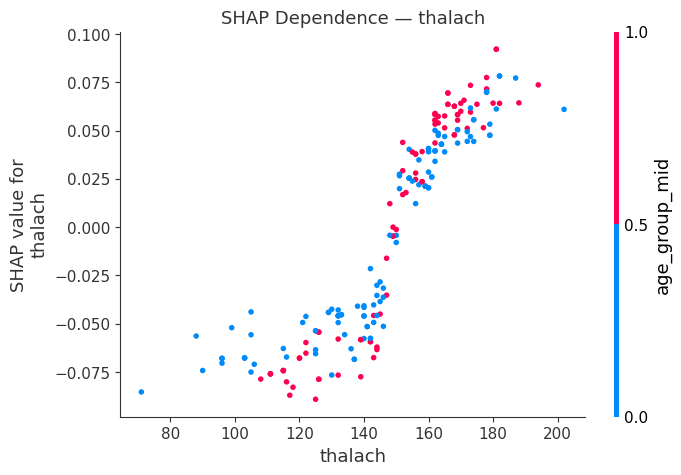

<Figure size 640x480 with 0 Axes>

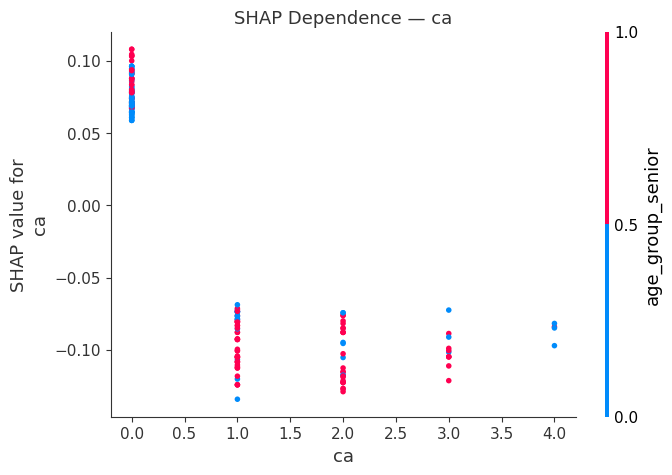

<Figure size 640x480 with 0 Axes>

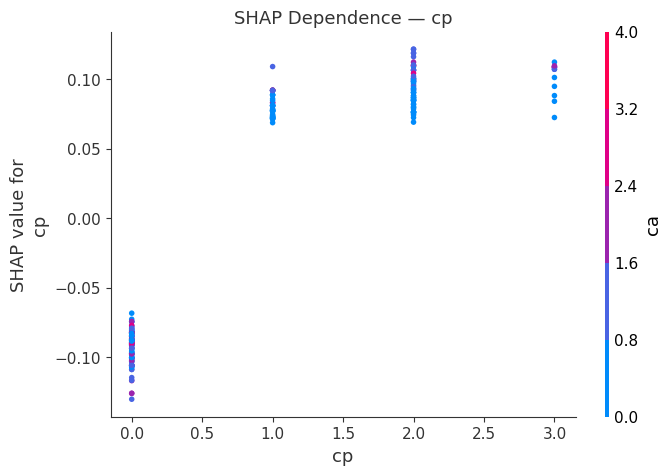

<Figure size 640x480 with 0 Axes>

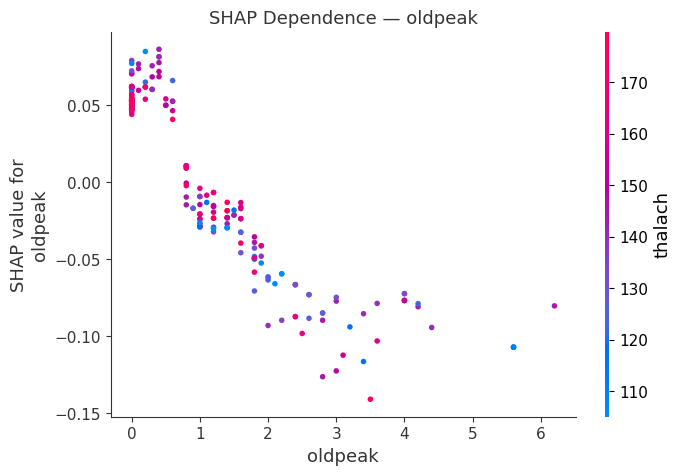

<Figure size 640x480 with 0 Axes>

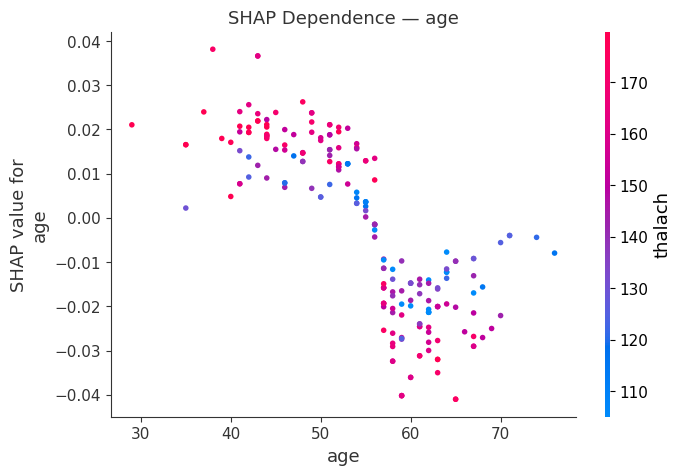

<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Top features from summary plot to investigate ---
top_features = ["thalach", "ca", "cp", "oldpeak", "age"]

for feature in top_features:
    shap.dependence_plot(
        feature,
        shap_values.values[:, :, 1],   # SHAP values for class 1
        X_test,
        interaction_index="auto",       # auto-picks strongest interacting feature
        title=f"SHAP Dependence — {feature}"
    )
    plt.tight_layout()
    plt.show()

In [ ]:
print(shap_values.values.shape)

(205, 20, 2)


In [ ]:
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'high_chol', 'age_group_mid',
       'age_group_senior', 'age_group_elder', 'bp_level_normal',
       'bp_level_high', 'bp_level_very_high'],
      dtype='object')


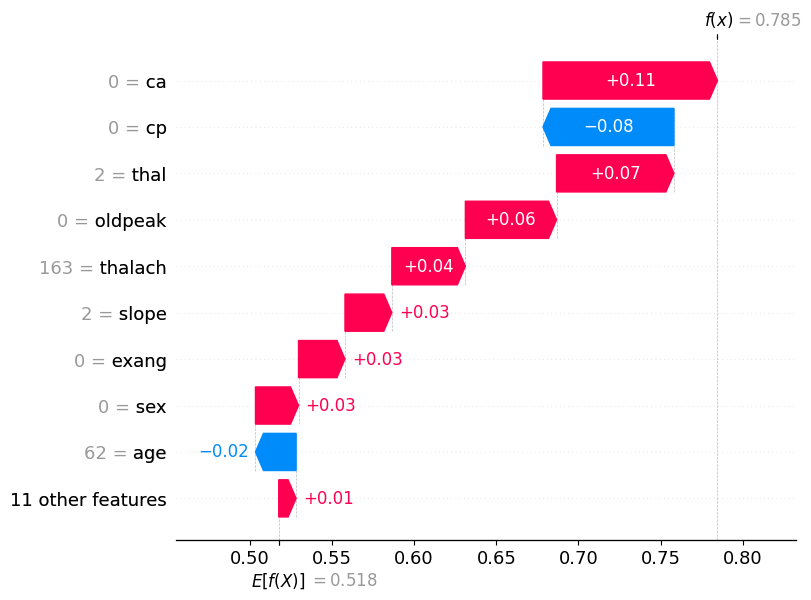

In [ ]:
shap.plots.waterfall(shap_values[0,:,1])

In [ ]:
fn_indices = (y_test == 1) & (y_pred_custom == 0)
X_fn = X_test[fn_indices]

In [ ]:
fn_indices = (y_test == 1) & (y_pred_custom == 0)

In [ ]:
fn_index_list = X_test[fn_indices].index
print(fn_index_list)

Index([983, 377, 528, 361], dtype='int64')


In [ ]:
fn_index = fn_index_list[0]

In [ ]:
fn_pos = X_test.index.get_loc(fn_index)

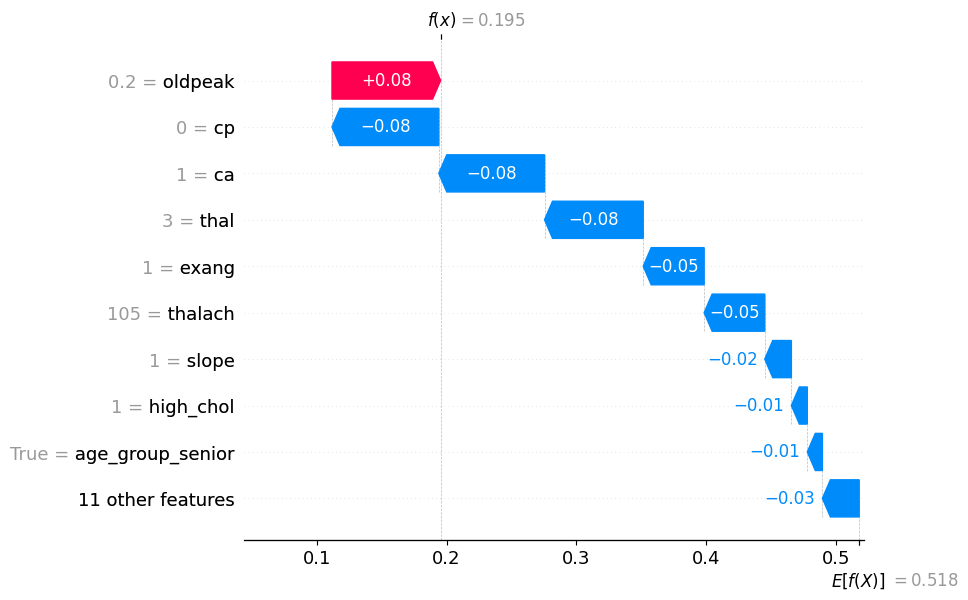

In [ ]:
shap.plots.waterfall(shap_values[fn_pos, :, 1])

In [ ]:
#Base value: E[f(x)] = 0.518 (average prediction)
#Final prediction: f(x) = 0.195

#👉 Since this is low (< threshold) → model predicted No Disease
#👉 But actual = Disease → ❌ False Negative